# Set Up Environment
This notebook loads the Tanks and Temples Barn reconstruction with `pycolmap` and prepares utilities for visualization.

In [1]:
from __future__ import annotations

import importlib.util
import sys
from itertools import islice
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pycolmap

plt.rcParams["figure.figsize"] = (12, 6)

# Ensure the repository root is on the module search path
repo_root = Path.cwd()
if not (repo_root / "04_tanks_and_temples_barn.py").exists():
    repo_root = repo_root.parent
sys.path.append(str(repo_root))

module_path = repo_root / "04_tanks_and_temples_barn.py"
spec = importlib.util.spec_from_file_location("barn_loader", module_path)
barn_loader = importlib.util.module_from_spec(spec)
sys.modules["barn_loader"] = barn_loader
spec.loader.exec_module(barn_loader)

print(f"Loaded helper module from {module_path}")

Loaded helper module from c:\Users\jackd\source\colmap-experiments\04_tanks_and_temples_barn.py


# Load Sample Data
Read the pose log to collect the original camera trajectories for the Barn sequence.

In [2]:
dataset_root = repo_root / "data" / "barn"
pose_log_path = dataset_root / "Barn_COLMAP_SfM.log"
image_dir = dataset_root / "images"

pose_entries = barn_loader.parse_pose_log(pose_log_path)
print(f"Parsed {len(pose_entries)} camera poses from {pose_log_path.name}")

def camera_centers_from_pose(rotation: np.ndarray, translation: np.ndarray) -> np.ndarray:
    # Convert world-to-camera transform into camera center in world coordinates
    return (-rotation.T @ translation).reshape(-1)

original_camera_centers = np.stack(
    [camera_centers_from_pose(entry.rotation, entry.translation) for entry in pose_entries]
)

print("Sample camera centers (first 3):")
for idx, center in enumerate(original_camera_centers[:3]):
    print(f"  #{idx + 1}: {center}")

Parsed 410 camera poses from Barn_COLMAP_SfM.log
Sample camera centers (first 3):
  #1: [0.89750841 0.09073233 3.17177467]
  #2: [0.98950759 0.09359618 3.17627863]
  #3: [1.09245541 0.10774096 3.17154515]


# Apply Reconstruction Algorithm
Use the utility loader to build a `pycolmap.Reconstruction` object that merges the pose log with the provided sparse point cloud.

In [3]:
reconstruction = barn_loader.load_barn(dataset_root, camera_model="PINHOLE", fx=None, fy=None, cx=None, cy=None)
print(reconstruction.summary())

# Extract camera centers from the reconstruction for comparison
recon_camera_centers = np.stack([img.projection_center().reshape(-1) for img in reconstruction.images.values()])

# Reservoir-style sampling of 3D points for plotting
sample_size = min(50000, reconstruction.num_points3D())
sampled_points = np.stack([point.xyz for point in islice(reconstruction.points3D.values(), sample_size)])

print(f"Sampled {sample_size} sparse points for visualization")

Reconstruction:
	num_rigs = 1
	num_cameras = 1
	num_frames = 410
	num_reg_frames = 410
	num_images = 410
	num_points3D = 11165399
	num_observations = 0
	mean_track_length = 0
	mean_observations_per_image = 0
	mean_reprojection_error = 0
Sampled 50000 sparse points for visualization
Sampled 50000 sparse points for visualization


# Plot Original and Reconstructed Data
Visualize the logged camera trajectory beside the sampled sparse point cloud from the reconstruction.

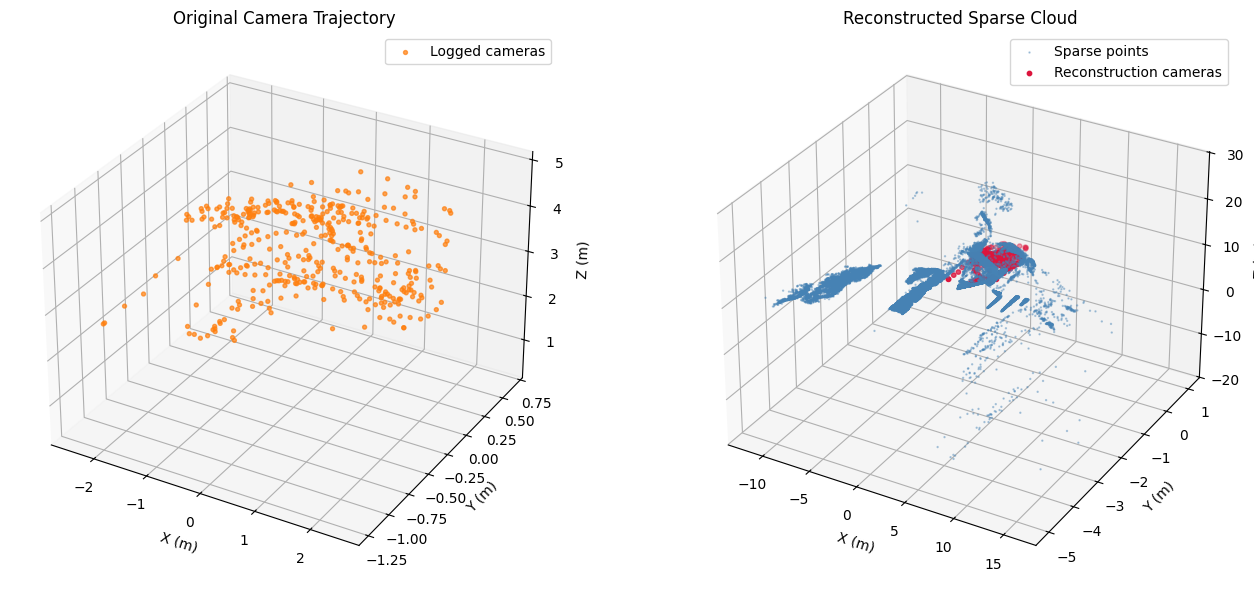

In [4]:
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(
    original_camera_centers[:, 0],
    original_camera_centers[:, 1],
    original_camera_centers[:, 2],
    s=8,
    c="tab:orange",
    alpha=0.7,
    label="Logged cameras",
)
ax1.set_title("Original Camera Trajectory")
ax1.set_xlabel("X (m)")
ax1.set_ylabel("Y (m)")
ax1.set_zlabel("Z (m)")
ax1.legend(loc="upper right")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(
    sampled_points[:, 0],
    sampled_points[:, 1],
    sampled_points[:, 2],
    s=0.5,
    c="steelblue",
    alpha=0.4,
    label="Sparse points",
)
ax2.scatter(
    recon_camera_centers[:, 0],
    recon_camera_centers[:, 1],
    recon_camera_centers[:, 2],
    s=10,
    c="crimson",
    label="Reconstruction cameras",
)
ax2.set_title("Reconstructed Sparse Cloud")
ax2.set_xlabel("X (m)")
ax2.set_ylabel("Y (m)")
ax2.set_zlabel("Z (m)")
ax2.legend(loc="upper right")

fig.tight_layout()
plt.show()